In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [104]:
test = pd.read_csv("/Users/hayashieijun/Desktop/STT project/Flight dataset/test.csv")
train = pd.read_csv("/Users/hayashieijun/Desktop/STT project/Flight dataset/train.csv")
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [105]:
test = test.drop(columns=['id','Unnamed: 0'], axis=1)
test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [161]:
# Checking the data is consistent
train['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [107]:
train['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [108]:
#checking the numerical columns
test_num_col = test.select_dtypes(include=['int64', 'float64'])
test_num_col.columns.tolist()

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

In [109]:
#checking the objective columns
test_obj_col = test.select_dtypes(include=['object'])
test_obj_col.columns.tolist()

['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

In [110]:
#encoding the column of gender and customer type
test['Gender'] = test['Gender'].astype(str).str.strip()
test['Customer Type'] = test['Customer Type'].astype(str).str.strip()
test['satisfaction'] = test['satisfaction'].astype(str).str.strip()
mapping = {'Male': 0, 'Female': 1, 'Loyal Customer': 0, 'disloyal Customer': 1, 'neutral or dissatisfied': 0, 'satisfied': 1}
test['Gender'] = test['Gender'].map(mapping)
test['Customer Type'] = test['Customer Type'].map(mapping)
test['satisfaction'] = test['satisfaction'].map(mapping)
test.head().T

,0,1,2,3,4
Gender,1,1,0,0,1
Customer Type,0,0,1,0,0
Age,52,36,20,44,49
Type of Travel,Business travel,Business travel,Business travel,Business travel,Business travel
Class,Eco,Business,Eco,Business,Eco
Flight Distance,160,2863,192,3377,1182
Inflight wifi service,5,1,2,0,2
Departure/Arrival time convenient,4,1,0,0,3
Ease of Online booking,3,3,2,0,4
Gate location,4,1,4,2,3


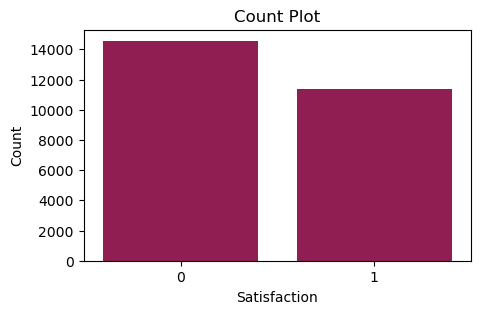

In [165]:
plt.figure(figsize=(5,3))
sns.countplot(x='satisfaction', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

In [111]:
cor_matrix = test.select_dtypes(include=[np.number]).corr() #select only numerical columns
sat_test_cor = cor_matrix['satisfaction'].sort_values(ascending=False) #Order the value from higher to lower
sat_test_cor

satisfaction                         1.000000
Online boarding                      0.494526
Inflight entertainment               0.398951
Seat comfort                         0.346275
On-board service                     0.321491
Cleanliness                          0.314350
Leg room service                     0.309629
Flight Distance                      0.295292
Inflight wifi service                0.280395
Baggage handling                     0.252415
Inflight service                     0.245573
Checkin service                      0.241495
Food and drink                       0.216868
Ease of Online booking               0.157709
Age                                  0.121697
Gender                              -0.007335
Gate location                       -0.016627
Departure Delay in Minutes          -0.051635
Arrival Delay in Minutes            -0.061059
Departure/Arrival time convenient   -0.064798
Customer Type                       -0.179632
Name: satisfaction, dtype: float64

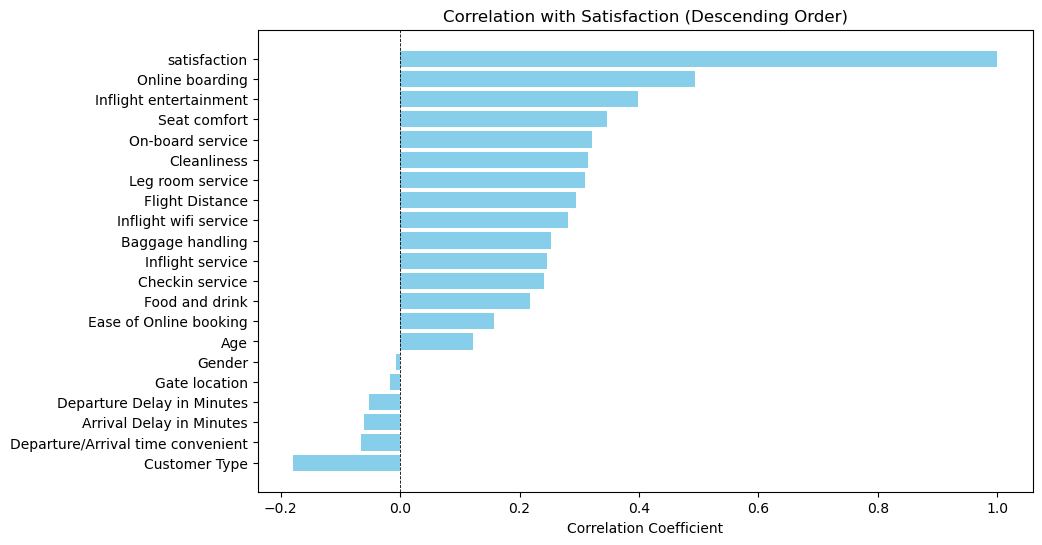

In [112]:
# Visualize correlation
mass_correlations = cor_matrix['satisfaction'].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(mass_correlations.index, mass_correlations.values, color='skyblue')
plt.xlabel('Correlation Coefficient')
plt.title('Correlation with Satisfaction (Descending Order)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.6)
plt.show()

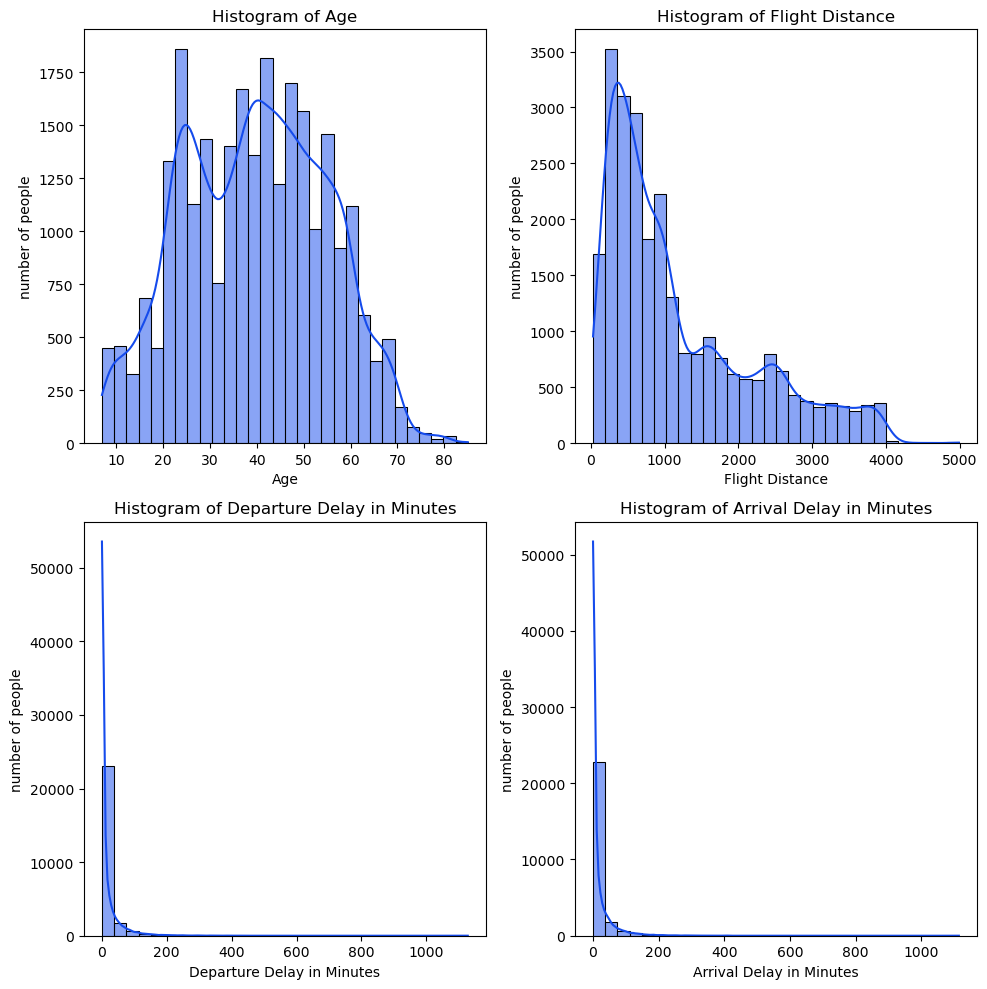

In [167]:
plt.figure(figsize=(10,10))
plt.subplot(2 ,2 ,1)
sns.histplot(test["Age"], bins=30, kde=True, color="#154BEC")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("number of people")

plt.subplot(2 ,2 ,2)
sns.histplot(test["Flight Distance"], bins=30, kde=True, color="#154BEC")
plt.title("Histogram of Flight Distance")
plt.xlabel("Flight Distance")
plt.ylabel("number of people")

plt.subplot(2 ,2 ,3)
sns.histplot(test["Departure Delay in Minutes"], bins=30, kde=True, color="#154BEC")
plt.title("Histogram of Departure Delay in Minutes")
plt.xlabel("Departure Delay in Minutes")
plt.ylabel("number of people")

plt.subplot(2 ,2 ,4)
sns.histplot(test["Arrival Delay in Minutes"], bins=30, kde=True, color="#154BEC")
plt.title("Histogram of Arrival Delay in Minutes")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("number of people")
plt.tight_layout()
plt.show()

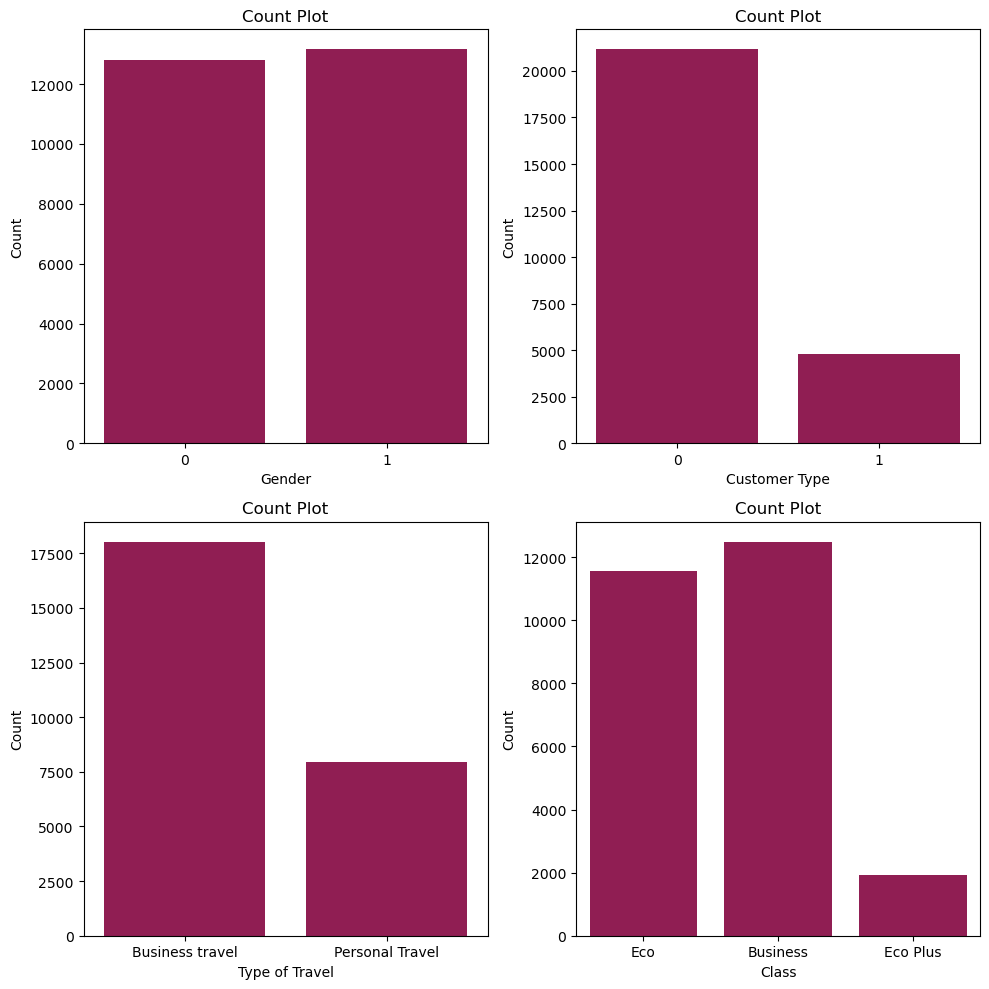

In [155]:
plt.figure(figsize=(10,10))
plt.subplot(2 ,2 ,1)
sns.countplot(x='Gender', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.subplot(2 ,2 ,2)
sns.countplot(x='Customer Type', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Customer Type')
plt.ylabel('Count')

plt.subplot(2 ,2 ,3)
sns.countplot(x='Type of Travel', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Type of Travel')
plt.ylabel('Count')

plt.subplot(2 ,2 ,4)
sns.countplot(x='Class', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


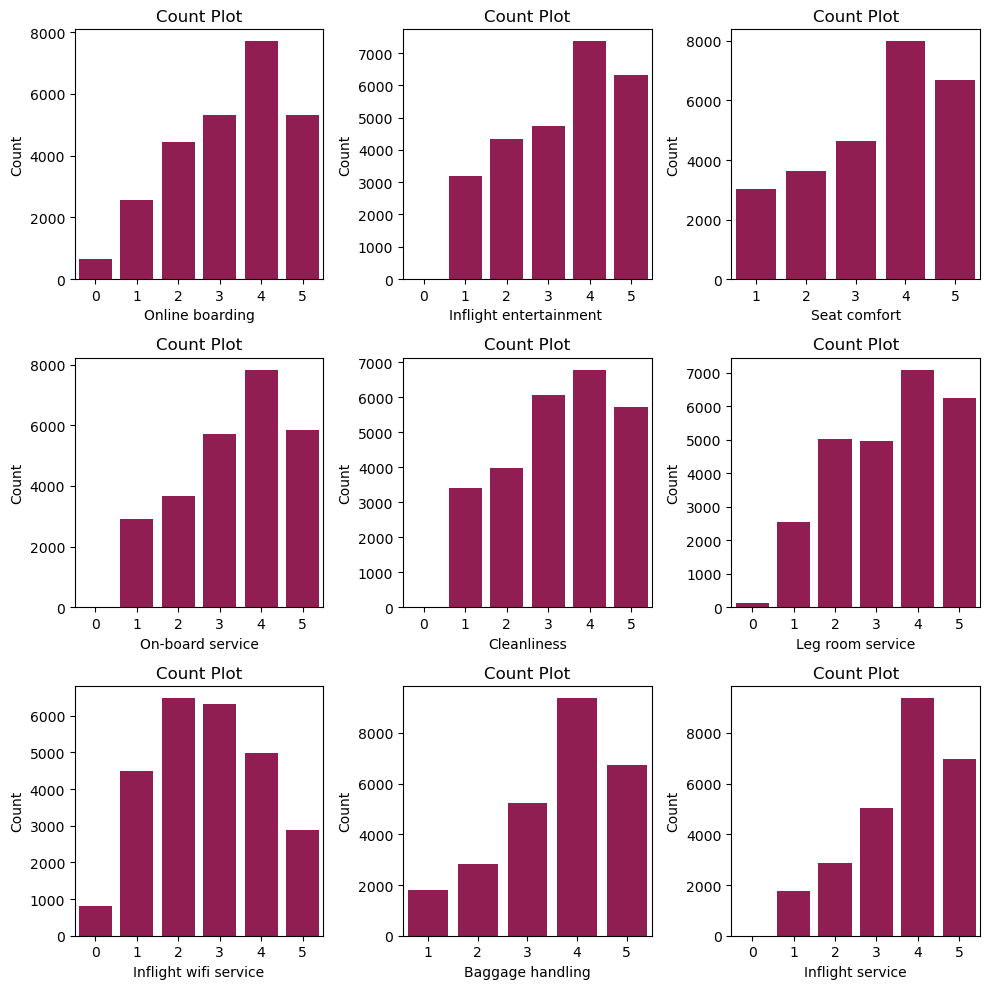

In [154]:
plt.figure(figsize=(10,10))
plt.subplot(3 ,3 ,1)
sns.countplot(x='Online boarding', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Online boarding')
plt.ylabel('Count')

plt.subplot(3 ,3 ,2)
sns.countplot(x='Inflight entertainment', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Inflight entertainment ')
plt.ylabel('Count')

plt.subplot(3 ,3 ,3)
sns.countplot(x='Seat comfort', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Seat comfort')
plt.ylabel('Count')

plt.subplot(3 ,3 ,4)
sns.countplot(x='On-board service', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('On-board service')
plt.ylabel('Count')

plt.subplot(3 ,3 ,5)
sns.countplot(x='Cleanliness', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Cleanliness')
plt.ylabel('Count')

plt.subplot(3 ,3 ,6)
sns.countplot(x='Leg room service', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Leg room service')
plt.ylabel('Count')

plt.subplot(3 ,3 ,7)
sns.countplot(x='Inflight wifi service', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Inflight wifi service')
plt.ylabel('Count')

plt.subplot(3 ,3 ,8)
sns.countplot(x='Baggage handling', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Baggage handling')
plt.ylabel('Count')

plt.subplot(3 ,3 ,9)
sns.countplot(x='Inflight service', data=test, color="#A30B52")
plt.title('Count Plot')
plt.xlabel('Inflight service')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Satisfaction by Flight Class')

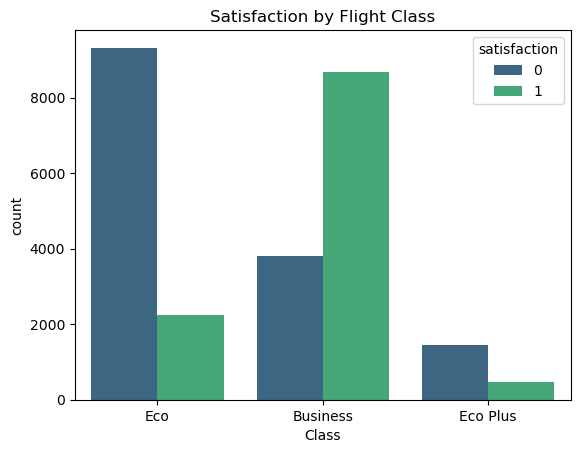

In [160]:
sns.countplot(data=test, x='Class', hue='satisfaction', palette='viridis')
plt.title('Satisfaction by Flight Class')